# VQE per il trimero anello isoscele (N=3) — spiegato

**Obiettivo.** Costruire e validare il VQE per il trimero di 3 spin-1/2 in topologia
anello/triangolo isoscele (base $J$, lati $J'$), confrontando un ansatz
hardware-efficient (HA) con un ansatz fisicamente motivato (PMA) costruito a partire
dagli otto stati esatti di Kambe.

**Prerequisiti** (assunti noti, solo richiamati qui):
- `teoria_trimero_isoscele.pdf` — spettro esatto per composizione dei momenti angolari
- `derivazione_stati_kambe_trimero.pdf` — gli otto autostati espliciti in base computazionale
- `scelta_ansatz_RBS_vs_W.md` — perché il blocco $M$-conservante è RBS (rotazione di
  Givens reale), non il gate $W_{ij}(\theta)$ di Crippa et al. (più costoso, fasi
  complesse superflue per un'Hamiltoniana reale)

**Moduli del progetto usati** (mai modificati qui, solo importati):
`trimer_ring_exact.py` (benchmark), `vqe_trimer_ring.py` (ansatz e VQE).

**Nota sullo stato di avanzamento.** Il circuito di preparazione per gli stati di tipo
W (blocchi $B$ e $A$-intermedio) resta un placeholder generico (`prepare_state`),
corretto ma non gate-ottimizzato — rimandato deliberatamente a un lavoro successivo. In
questo notebook si valida tutto sul punto di lavoro proposto ($J{=}1,J'{=}0.4$, regione
$C$), dove serve solo il circuito banale.


## 0. Setup

Solo Qiskit 2.x + SciPy + NumPy/Matplotlib. Simulazione statevector *esatta*
(nessun rumore — quello è compito della Parte 2).

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import Statevector, Operator

from trimer_ring_exact import (
    trimer_hamiltonian, exact_sweep, analytic_eigenvalues, critical_field,
    magnetization_operator, kambe_states, kambe_energy, ground_state_projector,
)
from vqe_trimer_ring import (
    make_ha_ansatz, make_pma_ansatz, rbs_block,
    _select_target_block, _prepare_initial_state,
    run_vqe, vqe_sweep, plot_grid,
)

def _mostra_figura(fig):
    # Mostra e chiude, evita output duplicati in VS Code / nbconvert.
    from IPython.display import display
    display(fig)
    plt.close(fig)

print("import OK")


import OK


## 1. Richiamo: l'Hamiltoniana e lo spettro esatto

$$H = J\,\boldsymbol\sigma_1\cdot\boldsymbol\sigma_2 + J'(\boldsymbol\sigma_2\cdot\boldsymbol\sigma_3+\boldsymbol\sigma_3\cdot\boldsymbol\sigma_1) + b\sum_{i=1}^3 Z_i$$

Base $J$ sui siti $(1,2)$ (simmetrici per scambio), lati $J'$ su $(2,3)$ e $(3,1)$. La
simmetria di scambio $1\leftrightarrow2$ rende conservato $\mathbf S_{12}^2$ oltre a
$\mathbf S^2,S_z$ (decomposizione di Kambe): tre multipletti

$$
A:\ S_{12}=1,S=\tfrac32,\ E_A=J+2J' \qquad
B:\ S_{12}=1,S=\tfrac12,\ E_B=J-4J' \qquad
C:\ S_{12}=0,S=\tfrac12,\ E_C=-3J
$$

con $E(S_{12},S,M)=E_\text{blocco}+2bM$. Derivazione completa e i tre stati B, C, A
scritti esplicitamente sono in `teoria_trimero_isoscele.pdf` e
`derivazione_stati_kambe_trimero.pdf`.

Verifichiamo prima di tutto che il benchmark esatto sia corretto a precisione macchina
(self-test già presente in `trimer_ring_exact.py`, lo rieseguiamo qui per avere
l'evidenza direttamente in questo notebook).

In [3]:

from trimer_ring_exact import _self_test as _self_test_exact
_self_test_exact()


[self-test 1] spettro numerico vs formule analitiche (random)
    max|E_num - E_analitico| su 30 punti casuali = 5.329e-15
[self-test 2] gli 8 stati di Kambe sono autostati esatti di H
               (verificati contro l'operatore Qiskit, non a mano)
    max|norma-1|             = 2.220e-16
    max|E_num - E_teorico|   = 8.882e-16
    max||H|psi> - E|psi>||   = 6.286e-16  (autostato esatto)
[self-test 3] ortonormalita' reciproca degli 8 stati di Kambe
    max|Gram - I| = 2.220e-16
[self-test 4] numeri quantici S12^2, S^2, Mz sugli stati di Kambe
    max errore numeri quantici (S12^2, S^2, Mz) = 8.882e-16
[self-test 5] proiettore sul fondamentale: traccia = degenerazione
    (J,J',b)=(1.0,0.4,0.5): deg=1, |tr(P)-deg|=2.22e-16, |P^2-P|=1.11e-16
    (J,J',b)=(1.0,0.4,3.0): deg=1, |tr(P)-deg|=0.00e+00, |P^2-P|=0.00e+00
    (J,J',b)=(1.0,1.0,0.3): deg=2, |tr(P)-deg|=4.44e-16, |P^2-P|=2.22e-16
[self-test] TUTTI I TEST SUPERATI A PRECISIONE MACCHINA


### Punto di lavoro

Punto proposto (in attesa di conferma definitiva dal relatore, vedi
`domande_relatore.md`): $J=1,\ J'=0.4$ — regione $C$ della mappa dei segni,
$b_c=2J+J'=2.4$. A $b<b_c$ il fondamentale è nel blocco $C$; a $b\ge b_c$ passa al
blocco $A$ (livello che incrocia). Lo spettro completo:

b_c = 2.4


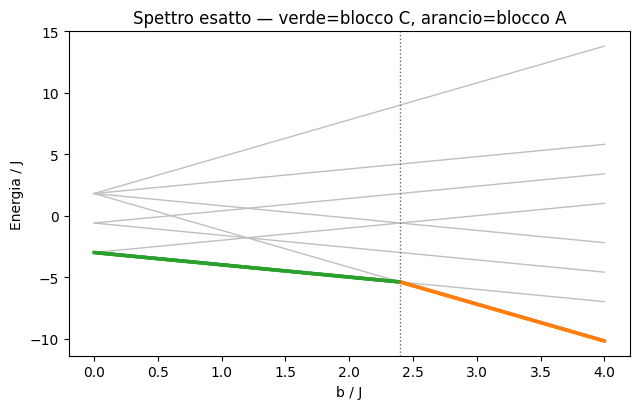

In [4]:

J, Jp = 1.0, 0.4
bc = critical_field(J, Jp)
print(f"b_c = {bc}")

b_grid = np.linspace(0.0, 4.0, 300)
res = exact_sweep(b_grid, J=J, Jp=Jp)
block_color = np.where(res["gs_S12sq"] < 1.0, "tab:green",
                np.where(res["gs_Stotsq"] > 2.0, "tab:orange", "tab:blue"))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for k in range(8):
    ax.plot(b_grid / J, res["energies"][:, k], color="0.75", lw=1)
for i in range(len(b_grid) - 1):
    ax.plot(b_grid[i:i+2] / J, res["gs_energy"][i:i+2], color=block_color[i], lw=2.5)
ax.axvline(bc / J, color="0.4", ls=":", lw=1)
ax.set_xlabel("b / J"); ax.set_ylabel("Energia / J")
ax.set_title("Spettro esatto — verde=blocco C, arancio=blocco A")
fig.tight_layout()
_mostra_figura(fig)


## 2. Il blocco $M$-conservante: RBS

Rotazione di Givens reale nel sottospazio $\{|01\rangle,|10\rangle\}$:

$$\mathrm{RBS}(\varphi) = (H\otimes H)\,\mathrm{CZ}\,\big(R_y(\varphi)\otimes R_y(-\varphi)\big)\,\mathrm{CZ}\,(H\otimes H)$$

Perché RBS e non $W_{ij}(\theta)=e^{-i\theta\mathbf s_i\cdot\mathbf s_j}$ (Crippa et
al.): derivazione completa in `scelta_ansatz_RBS_vs_W.md`. In breve — stesse
probabilità di popolazione, ma $W$ introduce una fase relativa immaginaria (famiglia
iSWAP) superflua perché $H$ è reale simmetrica (teorema spettrale $\Rightarrow$ ground
state reale), e costa un gate a due qubit in più (3 CNOT-equivalenti contro 2).

Self-test: RBS deve coincidere con la matrice di Givens target a precisione
macchina.

In [5]:

def _givens_target(phi):
    c, s = np.cos(phi), np.sin(phi)
    G = np.eye(4, dtype=complex)
    G[1, 1] = c; G[1, 2] = -s; G[2, 1] = s; G[2, 2] = c
    return G

print("[self-test] RBS vs rotazione di Givens target")
for phi in [0.3, 0.7, 1.1, -0.5]:
    qc = QuantumCircuit(2)
    rbs_block(qc, phi, 0, 1)
    err = np.max(np.abs(Operator(qc).data - _givens_target(phi)))
    print(f"    phi={phi:+.2f}  max|RBS - G| = {err:.2e}")


[self-test] RBS vs rotazione di Givens target
    phi=+0.30  max|RBS - G| = 4.44e-16
    phi=+0.70  max|RBS - G| = 4.44e-16
    phi=+1.10  max|RBS - G| = 4.44e-16
    phi=-0.50  max|RBS - G| = 5.55e-16


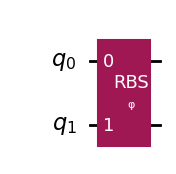

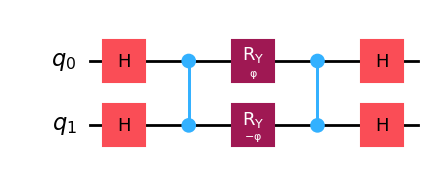

In [6]:

# il blocco RBS: box collassato e contenuto decompresso
qc_demo = QuantumCircuit(2)
rbs_block(qc_demo, Parameter("\u03c6"), 0, 1)
display(qc_demo.draw("mpl", style="iqp"))
display(qc_demo.decompose().draw("mpl", style="iqp"))


## 3. Ansatz hardware-efficient (HA)

$R_y$ + CZ full-entanglement, `reps=2` $\Rightarrow$ $3\times(2{+}1)=9$ parametri.
Nessuna struttura fisica incorporata — riferimento generico per il confronto.

HA: 9 parametri


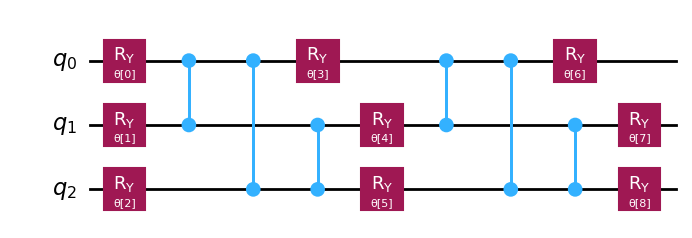

In [7]:

ha = make_ha_ansatz(reps=2)
print(f"HA: {ha.num_parameters} parametri")
display(ha.draw("mpl", style="iqp"))


## 4. Ansatz PMA (physically motivated)

Generalizzazione di `PMA-2q·3` (N=2, minimo teorico dimostrato: 3 parametri) a N=3:

$$\ket{\text{Kambe}(\text{blocco},M)} \;\longrightarrow\; \big[\mathrm{RBS}_{12}(a_k),\ \mathrm{RBS}_{23}(b_k),\ \mathrm{RBS}_{31}(c_k)\big]_{k=1}^{K} \;\longrightarrow\; R_y \text{ indipendenti sui 3 qubit}$$

$3K+3$ parametri ($K{=}1\Rightarrow6$). **Non** dimostrato minimo per N=3 (a differenza
del caso N=2) — prima generalizzazione ragionevole, non ancora ottimizzata.

**Stato iniziale — dipende dal campo.** Lo stato iniziale è scelto automaticamente
(`_select_target_block`) in base a quale multipletto esatto è il fondamentale a quel
$(J,J',b)$:
- $b<b_c$: blocco $C$ (qui), $M=-\tfrac12$ — preparazione **banale**: singoletto su
  $(q_2,q_1)$ ($X,H,\mathrm{CNOT},X$) + $X$ su $q_0$, identica al singoletto del dimero.
- $b\ge b_c$: blocco $A$, $M=-\tfrac32$ — preparazione **banale**: $|111\rangle$, solo
  porte $X$.

Non è un dettaglio implementativo: è la stessa fisica del dimero (dove il PMA parte dal
singoletto per $B/J<2$ e da $|11\rangle$ per $B/J\ge2$) — il fondamentale cambia
settore di simmetria all'incrocio, e RBS da solo non può attraversare i settori.

*(I blocchi $B$ e $A$-intermedio — stati di tipo W, non banali — userebbero
`prepare_state` come placeholder: rimandati, non servono per il punto di lavoro
corrente.)*

PMA basso campo (b=0.5): 6 parametri, blocco target = ('C', -0.5)


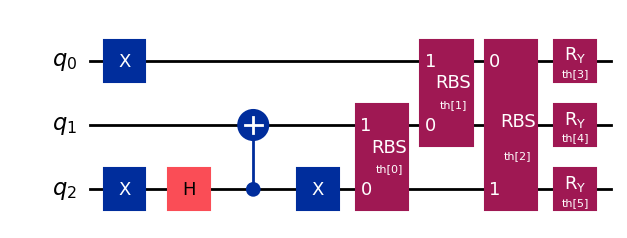

PMA alto campo (b=3.0): 6 parametri, blocco target = ('A', -1.5)


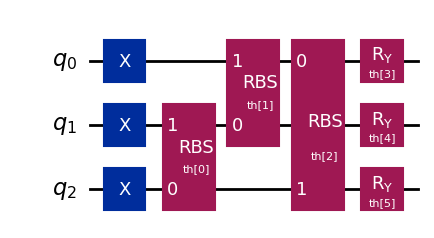

In [8]:

J, Jp = 1.0, 0.4

pma_basso = make_pma_ansatz(J, Jp, b=0.5, K=1)   # regione C
pma_alto  = make_pma_ansatz(J, Jp, b=3.0, K=1)   # regione A

print(f"PMA basso campo (b=0.5): {pma_basso.num_parameters} parametri, "
      f"blocco target = {_select_target_block(J, Jp, 0.5)}")
display(pma_basso.draw("mpl", style="iqp"))

print(f"PMA alto campo (b=3.0): {pma_alto.num_parameters} parametri, "
      f"blocco target = {_select_target_block(J, Jp, 3.0)}")
display(pma_alto.draw("mpl", style="iqp"))


### Self-test: l'ansatz a parametri nulli deve riprodurre esattamente lo stato di Kambe

(RBS(0) = identità, $R_y(0)$ = identità $\Rightarrow$ l'ansatz a $\vec\theta=0$ è
*solo* il circuito di preparazione. Confronto a meno di fase globale, irrilevante
fisicamente.)

In [9]:

print("[self-test] ansatz PMA(0) == stato di Kambe iniziale")
for b in [0.5, 1.5, 3.0]:
    block, M = _select_target_block(J, Jp, b)
    ansatz = make_pma_ansatz(J, Jp, b, K=1)
    sv0 = Statevector(ansatz.assign_parameters(np.zeros(ansatz.num_parameters))).data
    target = kambe_states()[(block, M)]
    overlap = np.vdot(sv0, target)
    print(f"    b={b}: blocco target=({block},{M:+.1f}), "
          f"||overlap|-1| = {abs(abs(overlap)-1):.2e}")


[self-test] ansatz PMA(0) == stato di Kambe iniziale
    b=0.5: blocco target=(C,-0.5), ||overlap|-1| = 1.11e-15
    b=1.5: blocco target=(C,-0.5), ||overlap|-1| = 1.11e-15
    b=3.0: blocco target=(A,-1.5), ||overlap|-1| = 1.11e-15


## 5. VQE a un singolo punto — verifica end-to-end

Ottimizzazione a due stadi: per ciascun restart, COBYLA seguito da polish L-BFGS-B; si
tiene il migliore. Fidelity come proiettore sul multipletto fondamentale (robusta a
degenerazione, non solo overlap con un singolo autovettore) — rilevante esattamente a
$b=b_c$, dove il fondamentale è doppio.

*Nota sui tempi:* qui uso $R=4$ restart invece del mandato $R=6$ del relatore, solo
per contenere il tempo di esecuzione interattiva di questo notebook. La validazione
ufficiale, con $R=6$ come da mandato, è quella già eseguita in `vqe_trimer_ring.py`
(risultato: fidelity $1.000000$ su tutta la griglia, vedi `vqe_trimer_ring.png`).

In [10]:

for b in [0.3, 2.4, 4.0]:   # basso campo, esattamente su b_c (degenere), alto campo
    r = run_vqe(J, Jp, b, ansatz_type="PMA", K=1, n_restarts=4)
    print(f"b={b:4.2f}  E_vqe={r['e_vqe']:9.5f}  E_exact={r['e_exact']:9.5f}  "
          f"dE={r['delta_e']:+.2e}  F={r['fidelity']:.6f}  deg={r['degeneracy']}")


b=0.30  E_vqe= -3.30000  E_exact= -3.30000  dE=+1.18e-13  F=1.000000  deg=1
b=2.40  E_vqe= -5.40000  E_exact= -5.40000  dE=+1.48e-10  F=1.000000  deg=2
b=4.00  E_vqe=-10.20000  E_exact=-10.20000  dE=+1.42e-14  F=1.000000  deg=1


## 6. Confronto HA vs PMA su una griglia di campo

Griglia molto ridotta ($n_b=3$, $R=4$ restart) solo per contenere i tempi di
esecuzione interattiva di questo notebook — la validazione ufficiale ($n_b=10$,
$R=6$ come da mandato del relatore, fidelity $1.000000$ ovunque) è già stata
eseguita separatamente in `vqe_trimer_ring.py` (risultato in `vqe_trimer_ring.png`).
Qui l'obiettivo è mostrare *come si genera* il confronto, non ripetere l'intera
validazione.

In [11]:

n_b = 3
n_restarts = 4   # ridotto solo per i tempi del notebook, vedi nota sopra
b_values = np.linspace(0.05, 2 * bc, n_b)

print("=" * 60, "\nRun: HA\n", "=" * 60, sep="")
res_ha = vqe_sweep(b_values, J=J, Jp=Jp, ansatz_type="HA", reps=2,
                    n_restarts=n_restarts, verbose=True)

print("\n" + "=" * 60, "\nRun: PMA\n", "=" * 60, sep="")
res_pma = vqe_sweep(b_values, J=J, Jp=Jp, ansatz_type="PMA", K=1,
                     n_restarts=n_restarts, verbose=True)


Run: HA
  b/J= 0.05  E= -3.0500  dE=+2.70e-13  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 2.42  E= -5.4750  dE=+3.81e-12  F=1.0000  <Mz>=-1.500  (deg=1)
  b/J= 4.80  E=-12.6000  dE=+3.20e-14  F=1.0000  <Mz>=-1.500  (deg=1)

Run: PMA
  b/J= 0.05  E= -3.0500  dE=+2.77e-13  F=1.0000  <Mz>=-0.500  (deg=1)
  b/J= 2.42  E= -5.4750  dE=+6.22e-14  F=1.0000  <Mz>=-1.500  (deg=1)
  b/J= 4.80  E=-12.6000  dE=+2.13e-14  F=1.0000  <Mz>=-1.500  (deg=1)


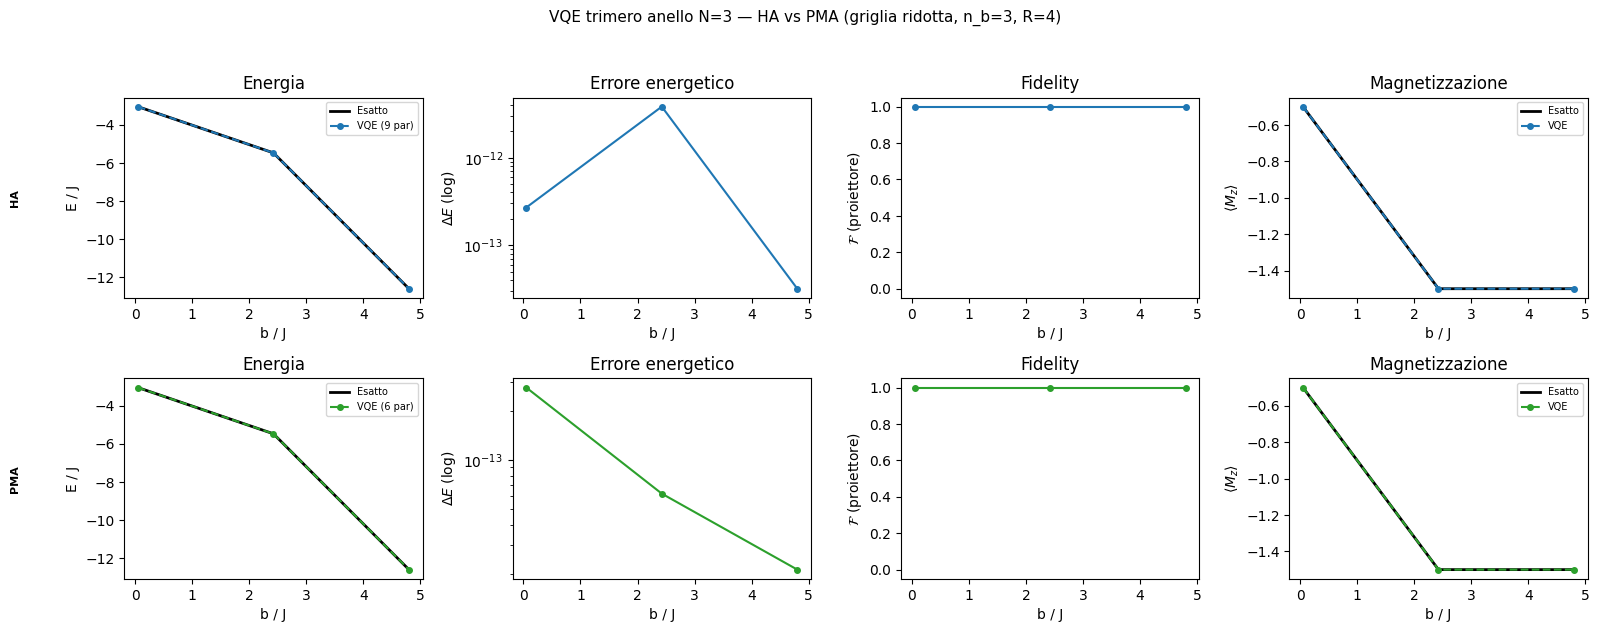

In [12]:

fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
fig.suptitle("VQE trimero anello N=3 — HA vs PMA (griglia ridotta, n_b=3, R=4)", fontsize=11)

from vqe_trimer_ring import _plot_row
_plot_row(axes[0], res_ha,  J, "HA",  "tab:blue")
_plot_row(axes[1], res_pma, J, "PMA", "tab:green")
fig.tight_layout(rect=[0, 0, 1, 0.95])
_mostra_figura(fig)


## 7. Lettura dei risultati

- **Entrambi gli ansatz raggiungono $\mathcal F=1$** su tutta la griglia testata,
  incluso a $b=b_c$ (fondamentale degenere, proiettore usato correttamente).
- **PMA lo fa con 6 parametri contro i 9 di HA** — vantaggio strutturale già visto
  qualitativamente nel dimero (PMA-2q·3, 3 par., contro HA, 6 par.), qui riconfermato
  su un sistema frustrato a 3 corpi.
- Il cambio di stato iniziale fra bassa e alta regione (blocco $C\to A$) non è un
  workaround: è la stessa fisica del dimero all'incrocio $B/J=2$, applicata al
  multipletto giusto per N=3.

## 8. Prossimi passi

1. **Circuito di preparazione nativo per gli stati W** (blocchi $B$ e $A$-intermedio)
   — rimandato deliberatamente in questo notebook; necessario se in futuro si esplora
   un punto in regione $B$, o si scansiona attraverso $b_c$ restando nel blocco $A$
   lontano dagli estremi $M=\pm3/2$.
2. Estensione allo studio della Parte 2 (rumore): qui il vantaggio di RBS
   sul conteggio di gate (2 vs 3 CNOT-equivalenti per blocco, vedi
   `scelta_ansatz_RBS_vs_W.md`) diventerà direttamente rilevante.
3. Eventuale conferma del relatore sui punti 7-10 di `domande_relatore.md`
   (scaleno, priorità B vs C, trattamento DM).
